In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import os
import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
from IPython.display import display

In [3]:
file_path = os.path.join("..", "data", "processed", "features_engineered.csv")

# Read CSV with index_col=0 to avoid unnamed column issues
data = pd.read_csv(file_path, index_col=0)
data

,Enrollment_ID,Study_Prog_Name,Study_Prog_Exam_Completed,Prior_Edu_Type,Prior_Edu_School_Location,Prior_Edu_Postcode,Prior_Edu_Country,Study_Prog_Group_Size,Student_Enrollment_Gap,Exit_Status
0,1536258,Teacher_Education,1,BUITENL_SL,0000_ABROAD,0000_ABROAD,outside_NL,1153,39.0,leaving_successfully
1,1909325,Communication,1,HAVO,HOORN_NH,Others,NL,1238,51.0,leaving_successfully
2,1920233,Bachelor_of_Law,1,HAVO,CULEMBORG,4103_NM,NL,2139,51.0,leaving_successfully
3,1548428,Communication,1,HAVO,ZEIST,3707_EP,NL,1238,61.0,leaving_successfully
4,1848231,Bachelor_of_Law,1,HAVO,ZEIST,3708_AG,NL,2139,125.0,leaving_successfully
...,...,...,...,...,...,...,...,...,...,...
5239,1752948,Information_Communication_Technology,0,BUITENL_SL,0000_ABROAD,0000_ABROAD,outside_NL,3215,326.0,switching_internally
5240,1601483,International_Business_Utrecht,0,HAVO,BAARN,3742_CS,NL,2008,9.0,switching_internally
5241,1853782,Social_Work,0,HAVO,ZUTPHEN,Others,NL,2723,47.0,switching_internally
5242,1853742,Bachelor_of_Law,0,HAVO,NIEUWEGEIN,3439_MV,NL,2139,47.0,switching_internally


In [4]:
data.columns

Index(['Enrollment_ID', 'Study_Prog_Name', 'Study_Prog_Exam_Completed',
       'Prior_Edu_Type', 'Prior_Edu_School_Location', 'Prior_Edu_Postcode',
       'Prior_Edu_Country', 'Study_Prog_Group_Size', 'Student_Enrollment_Gap',
       'Exit_Status'],
      dtype='object')

# Analyze which Study Programs have the most students in each Exit_Status category.

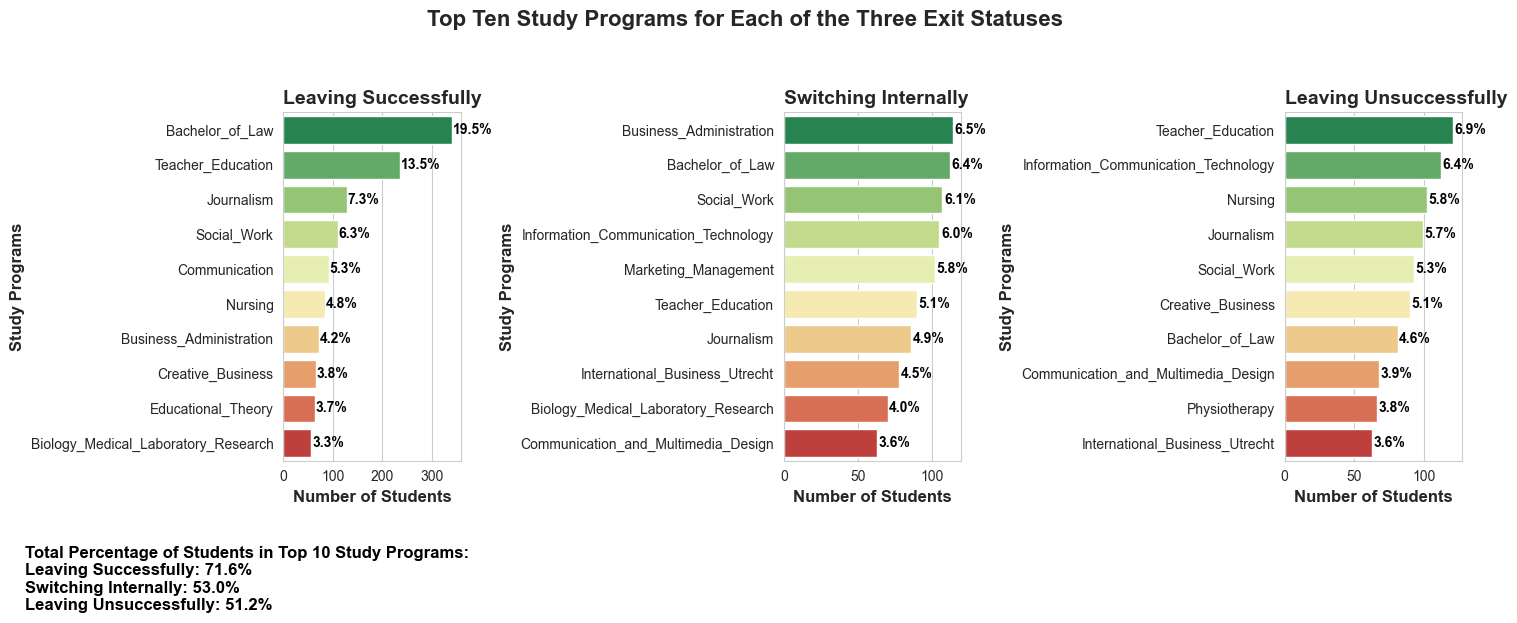

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(15, 6))

# Set the general title for the entire figure
plt.suptitle("Top Ten Study Programs for Each of the Three Exit Statuses", fontsize=16, fontweight='bold', y=1.05)

# Specify the order of the Exit_Status categories
status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']

# Dictionary to store total percentages for each category
total_percentages = {}

# Loop through each Exit_Status category in the specified order
for i, status in enumerate(status_order):
    plt.subplot(1, 3, i + 1)
    
    # Get total count for the current category
    total_count = data[data['Exit_Status'] == status]['Study_Prog_Name'].value_counts().sum()
    
    # Get top 10 study programs
    top_programs = data[data['Exit_Status'] == status]['Study_Prog_Name'].value_counts().nlargest(10)
    
    # Calculate percentages
    percentages = (top_programs / total_count) * 100
    
    # Compute total percentage for the top 10
    top_10_total_percentage = percentages.sum()
    total_percentages[status] = top_10_total_percentage  # Store the value

    # Set the color palette (Green at the top for all categories)
    palette = sns.color_palette("RdYlGn_r", len(top_programs))  # Green at top, Red at bottom

    # Create bar plot
    ax = sns.barplot(x=top_programs.values, y=top_programs.index, palette=palette)
    
    # Add percentage labels at the end of each bar
    for index, value in enumerate(top_programs.values):
        percentage_text = f"{percentages.iloc[index]:.1f}%"  # Format to 1 decimal place
        ax.text(value + 1, index, percentage_text, va='center', fontsize=10, fontweight='bold', color='black')

    # Title and labels for each subplot with left alignment
    plt.title(f"{status.replace('_', ' ').title()}", fontsize=14, fontweight='bold', loc='left')  # Specific title for each plot
    plt.xlabel("Number of Students", fontsize=12, fontweight='bold')
    plt.ylabel("Study Programs", fontsize=12, fontweight='bold')

# Adjust layout to make space for text below the plot
plt.tight_layout(rect=[0, 0.2, 1, 1])  # Leaves more space at the bottom

# Format summary text
summary_text = "\n".join([f"{status.replace('_', ' ').title()}: {total_percentages[status]:.1f}%" for status in status_order])

# Add total percentages below the plot, aligned to the left
plt.figtext(0.02, 0.05, f"Total Percentage of Students in Top 10 Study Programs:\n{summary_text}", 
            fontsize=12, fontweight='bold', color='black', ha='left')

# Show the plot
plt.show()


# Check if the gap between prior education and enrollment affects the exit status.

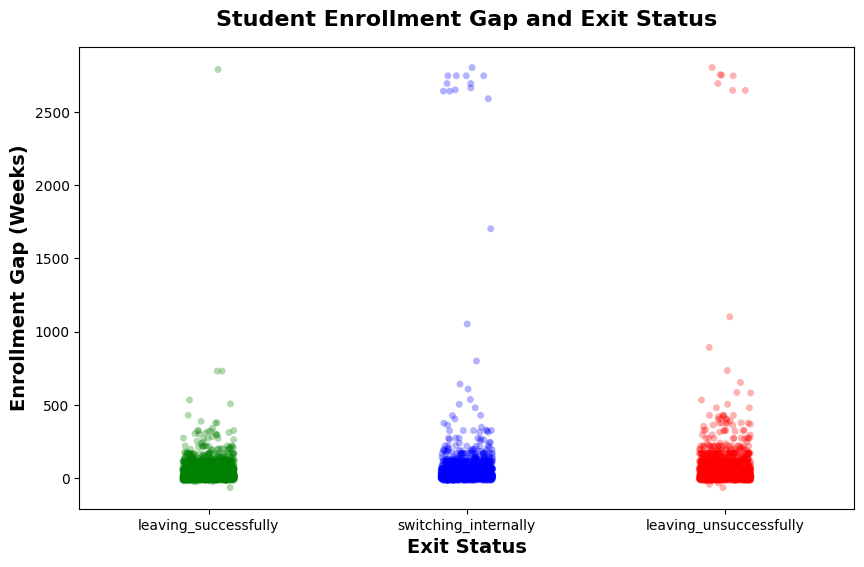

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 6))

# Set the general title for the plot
plt.title("Student Enrollment Gap and Exit Status", fontsize=16, fontweight='bold', pad=15)

# Define the Exit_Status categories and corresponding colors
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']
primary_colors = ['green', 'blue', 'red']

# Plot all three categories on one plot
sns.stripplot(x='Exit_Status', y='Student_Enrollment_Gap', 
              data=data, palette=primary_colors, jitter=True, alpha=0.3, order=exit_status_order)

# Title and labels for the plot
plt.xlabel("Exit Status", fontsize=14, fontweight='bold')
plt.ylabel("Enrollment Gap (Weeks)", fontsize=14, fontweight='bold')

# Show the plot
plt.show()


# See if larger study program group size have different dropout or switching rates.

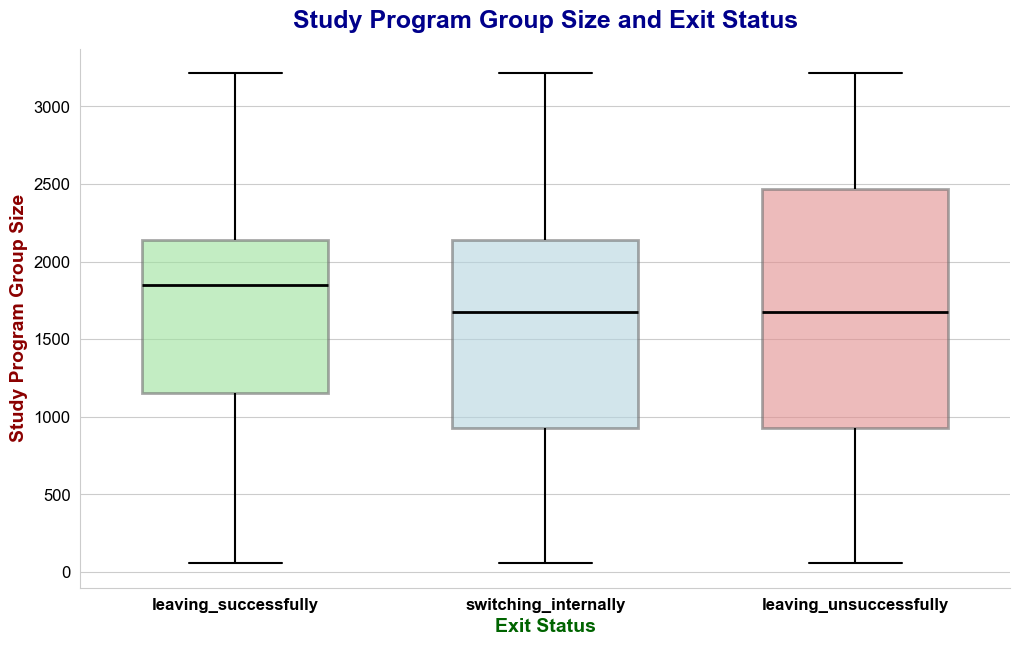

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style and color theme
sns.set_style("whitegrid")
sns.set_palette("pastel")

# Set figure size
plt.figure(figsize=(12, 7))

# Set the general title for the plot
plt.title("Study Program Group Size and Exit Status", fontsize=18, fontweight='bold', pad=15, color='darkblue')

# Define the Exit_Status categories and corresponding faded pastel colors
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']
primary_colors = ['#90EE90', '#ADD8E6', '#F08080']  # Faded green, blue, and red

# Create the boxplot with soft colors
sns.boxplot(
    x='Exit_Status', 
    y='Study_Prog_Group_Size', 
    data=data, 
    order=exit_status_order, 
    palette=primary_colors,
    width=0.6,  # Adjust box width
    linewidth=2,  # Slightly thicker edges
    fliersize=0,  # Hide outliers (data points)
    boxprops=dict(alpha=0.6),  # Slight transparency for soft colors
    whiskerprops=dict(color="black", linewidth=1.5),  # Black whiskers
    capprops=dict(color="black", linewidth=1.5),  # Black caps
    medianprops=dict(color="black", linewidth=2)  # Black median line
)

# Enhance labels and ticks
plt.xlabel("Exit Status", fontsize=14, fontweight='bold', color='darkgreen')
plt.ylabel("Study Program Group Size", fontsize=14, fontweight='bold', color='darkred')
plt.xticks(fontsize=12, fontweight='bold', color='black')
plt.yticks(fontsize=12, color='black')

# Remove top and right spines for a cleaner look
sns.despine()

# Show the plot
plt.show()


Insights:

Larger Study Program Groups and Success: The heatmap suggests that larger study programs (with an average group size of 1700) are associated with students who leave successfully.

Similar Group Sizes in Unsuccessful and Switching Internally: The group size is the same (1600) for students who either leave unsuccessfully or switch internally, which might indicate that the size of the study group isn't strongly affecting whether students switch or leave unsuccessfully.

# Analyze if students from certain prior education backgrounds have higher dropout rates.

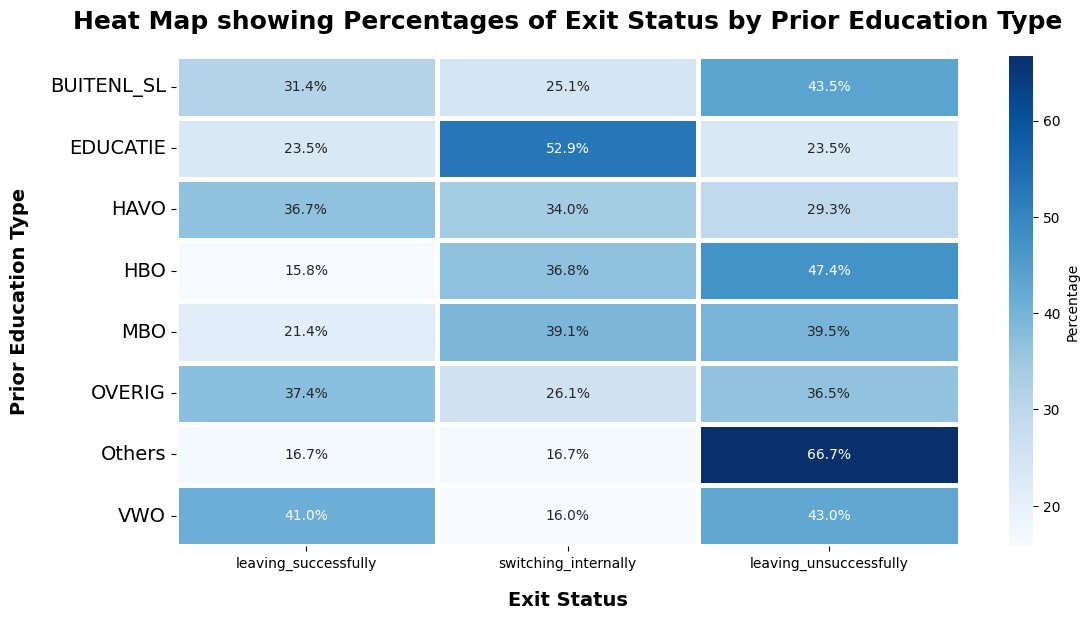

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Exit_Status is properly ordered
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']
data['Exit_Status'] = pd.Categorical(data['Exit_Status'], categories=exit_status_order, ordered=True)

# Create a contingency table (cross-tabulation) of counts
heatmap_data = pd.crosstab(data['Prior_Edu_Type'], data['Exit_Status'])

# Convert counts to percentages (row-wise)
heatmap_data_percentage = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Format values to include the % symbol
annot_labels = heatmap_data_percentage.applymap(lambda x: f"{x:.1f}%")

# If the heatmap_data is not empty, plot the heatmap
if not heatmap_data_percentage.empty:
    # Set figure size
    plt.figure(figsize=(14, 7))  # Keep large size for clarity

    # Plot the heatmap with percentage labels
    ax = sns.heatmap(
        heatmap_data_percentage, 
        annot=annot_labels, 
        cmap='Blues', 
        fmt="", 
        linewidths=2.5,  # Increased line width to create more spacing
        cbar_kws={'label': 'Percentage'}
    )

    # Adjust tick labels to increase vertical spacing
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, rotation=0, verticalalignment='center')

    # Title and labels
    plt.title("Heat Map showing Percentages of Exit Status by Prior Education Type", fontsize=18, fontweight='bold', pad=20)
    plt.xlabel("Exit Status", fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel("Prior Education Type", fontsize=14, fontweight='bold', labelpad=15)

    # Adjust layout to add vertical spacing
    plt.subplots_adjust(left=0.25, right=0.95, top=0.9, bottom=0.2)  

    # Show the plot
    plt.show()
else:
    print("Heatmap data is empty. Please check for missing values or unexpected data.")


# Prior_Edu_Country – see if students from specific countries have different exit statuses.

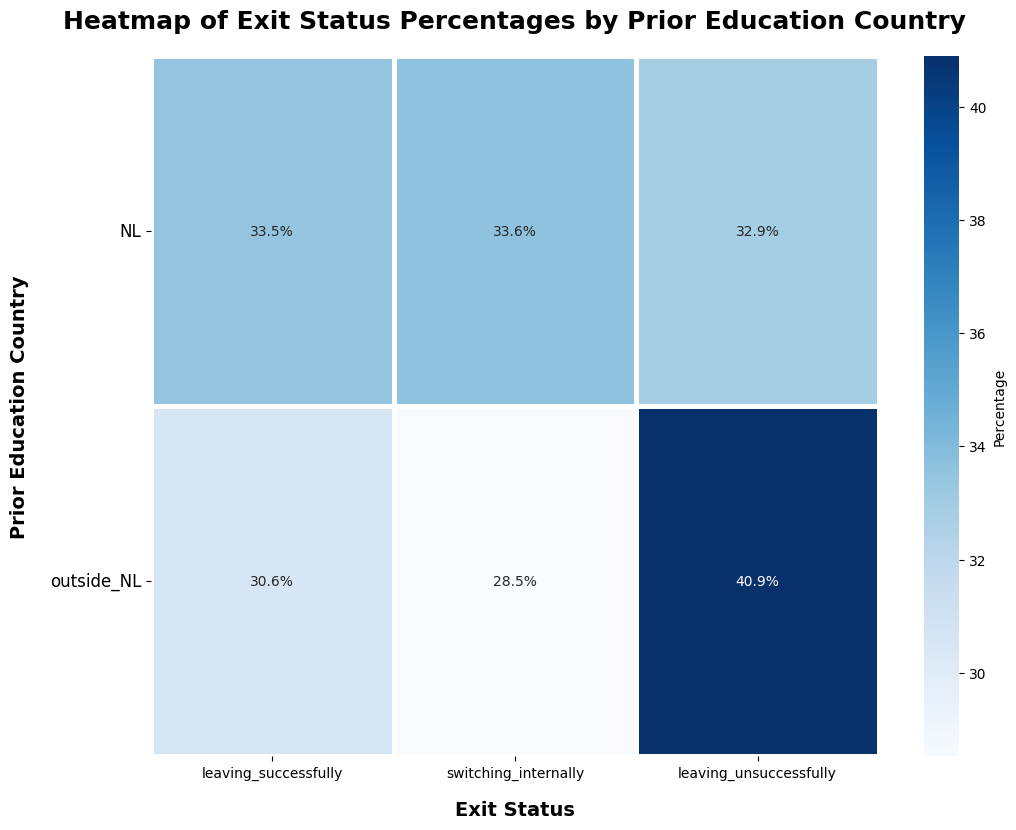

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Exit_Status is properly ordered
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']
data['Exit_Status'] = pd.Categorical(data['Exit_Status'], categories=exit_status_order, ordered=True)

# Create a contingency table (cross-tabulation) of counts
heatmap_data = pd.crosstab(data['Prior_Edu_Country'], data['Exit_Status'])

# Convert counts to percentages (row-wise)
heatmap_data_percentage = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Calculate the average percentage per Prior Education Country across all Exit_Statuses
heatmap_data_percentage["Avg_Percentage"] = heatmap_data_percentage.mean(axis=1)

# Sort by the highest average percentage if the ranking holds across all Exit_Statuses
if heatmap_data_percentage.rank(axis=0, method='min').var(axis=1).max() == 0:
    heatmap_data_percentage = heatmap_data_percentage.sort_values("Avg_Percentage", ascending=False)

# Drop the temporary Avg_Percentage column after sorting
heatmap_data_percentage = heatmap_data_percentage.drop(columns=["Avg_Percentage"])

# Format values to include the % symbol
annot_labels = heatmap_data_percentage.applymap(lambda x: f"{x:.1f}%")

# If the heatmap_data is not empty, plot the heatmap
if not heatmap_data_percentage.empty:
    # Set figure size
    plt.figure(figsize=(14, 10))  # Increased height for better spacing

    # Plot the heatmap with percentage labels
    ax = sns.heatmap(
        heatmap_data_percentage, 
        annot=annot_labels, 
        cmap='Blues', 
        fmt="", 
        linewidths=2.5,  # Increased line width for spacing
        cbar_kws={'label': 'Percentage'}
    )

    # Adjust tick labels for better readability
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, rotation=0, verticalalignment='center')

    # Title and labels
    plt.title("Heatmap of Exit Status Percentages by Prior Education Country", fontsize=18, fontweight='bold', pad=20)
    plt.xlabel("Exit Status", fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel("Prior Education Country", fontsize=14, fontweight='bold', labelpad=15)

    # Adjust layout to add vertical spacing
    plt.subplots_adjust(left=0.3, right=0.95, top=0.9, bottom=0.2)  

    # Show the plot
    plt.show()
else:
    print("Heatmap data is empty. Please check for missing values or unexpected data.")


# Study_Prog_Exam_Completed – Check if completing the program exam is linked to success or dropout.

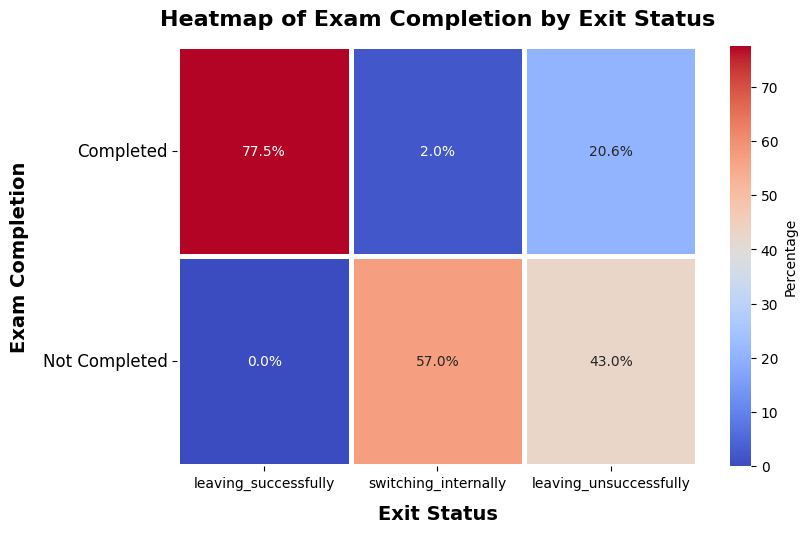

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Exit_Status is properly ordered
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']
data['Exit_Status'] = pd.Categorical(data['Exit_Status'], categories=exit_status_order, ordered=True)

# Rename values for better readability (0 = Not Completed, 1 = Completed)
data['Study_Prog_Exam_Completed'] = data['Study_Prog_Exam_Completed'].map({0: 'Not Completed', 1: 'Completed'})

# Create a contingency table (cross-tabulation) of counts
heatmap_data = pd.crosstab(data['Study_Prog_Exam_Completed'], data['Exit_Status'])

# Convert counts to percentages (row-wise normalization)
heatmap_data_percentage = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Format values to include the % symbol
annot_labels = heatmap_data_percentage.applymap(lambda x: f"{x:.1f}%")

# If the heatmap_data is not empty, plot the heatmap
if not heatmap_data_percentage.empty:
    # Set figure size
    plt.figure(figsize=(10, 6))

    # Plot the heatmap with percentage labels
    ax = sns.heatmap(
        heatmap_data_percentage, 
        annot=annot_labels, 
        cmap='coolwarm',  # Color gradient (Blue to Red)
        fmt="", 
        linewidths=2.5,  # Increased line width for spacing
        cbar_kws={'label': 'Percentage'}
    )

    # Adjust tick labels for better readability
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, rotation=0, verticalalignment='center')

    # Title and labels
    plt.title("Heatmap of Exam Completion by Exit Status", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Exit Status", fontsize=14, fontweight='bold', labelpad=10)
    plt.ylabel("Exam Completion", fontsize=14, fontweight='bold', labelpad=10)

    # Adjust layout for better spacing
    plt.subplots_adjust(left=0.3, right=0.95, top=0.9, bottom=0.2)  

    # Show the plot
    plt.show()
else:
    print("Heatmap data is empty. Please check for missing values or unexpected data.")


In [15]:
data.columns

Index(['Enrollment_ID', 'Study_Prog_Name', 'Study_Prog_Exam_Completed',
       'Prior_Edu_Type', 'Prior_Edu_School_Location', 'Prior_Edu_Postcode',
       'Prior_Edu_Country', 'Study_Prog_Group_Size', 'Student_Enrollment_Gap',
       'Exit_Status'],
      dtype='object')

# Test for correlation matrix using Cramér's V Correlation Matrix for categorical values

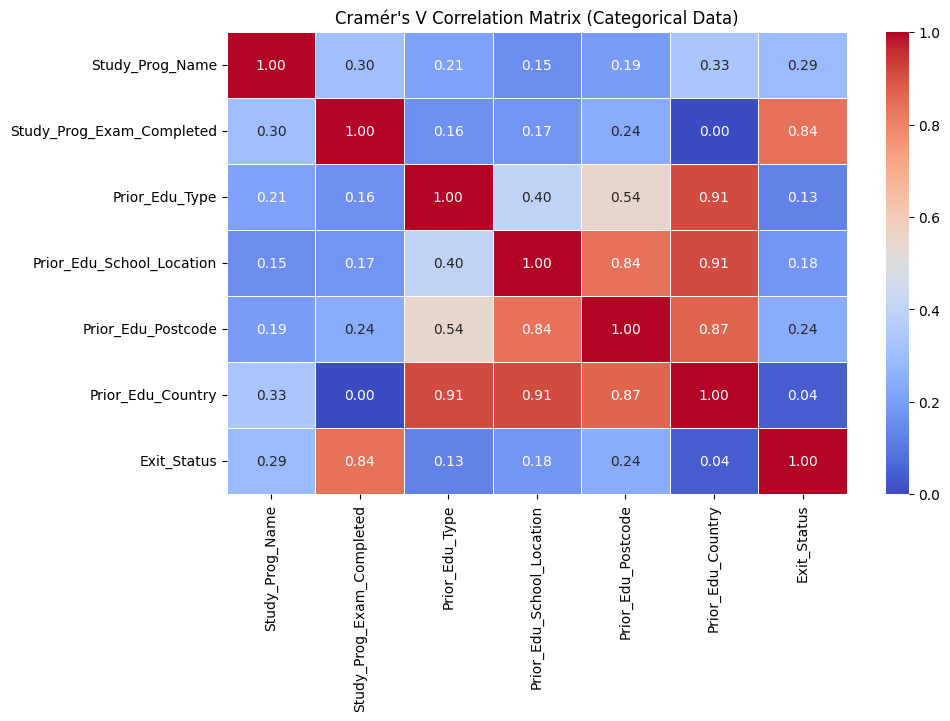

In [16]:
# Identify categorical columns dynamically
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

# Define function to calculate Cramér's V
def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical correlation."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0

# Compute Cramér’s V matrix for categorical variables
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0  # Perfect correlation with itself
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

# Convert values to float
cramers_v_matrix = cramers_v_matrix.astype(float)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cramers_v_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Cramér's V Correlation Matrix (Categorical Data)")
plt.show()


NEXT: 

Stepwise approach to remove highly correlated categorical variables based on Cramér's V:

Steps:
Compute the correlation matrix using Cramér's V.

Identify pairs of categorical variables with correlations above 0.7.

Iteratively remove one variable from each highly correlated pair (keeping the first occurrence).

Display the updated correlation matrix.

Columns to be removed due to high correlation (>0.7):
{'Prior_Edu_Country', 'Exit_Status', 'Prior_Edu_Postcode'}


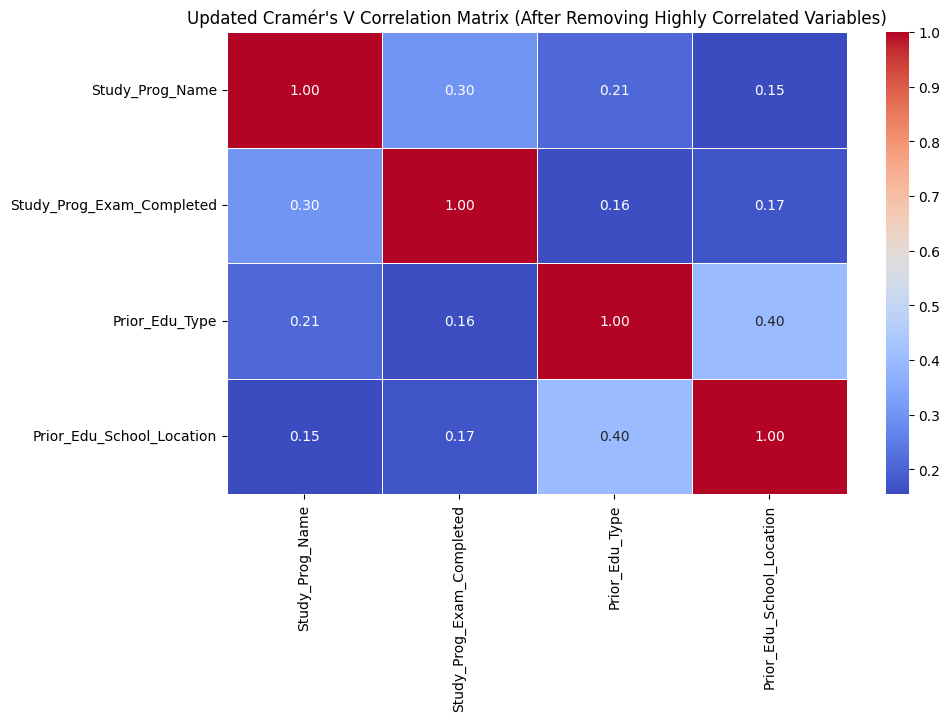

In [17]:

# Identify categorical columns dynamically
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

# Define function to calculate Cramér's V
def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical correlation."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0

# Compute Cramér’s V matrix for categorical variables
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0  # Perfect correlation with itself
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

# Convert values to float
cramers_v_matrix = cramers_v_matrix.astype(float)

# Identify columns to remove
to_remove = set()
for col in cramers_v_matrix.columns:
    if col not in to_remove:
        high_corr = cramers_v_matrix[col][(cramers_v_matrix[col] > 0.7) & (cramers_v_matrix[col] < 1.0)].index.tolist()
        to_remove.update(high_corr)

# Print columns to be removed
print("Columns to be removed due to high correlation (>0.7):")
print(to_remove)

# Drop highly correlated columns
data_filtered = data.drop(columns=to_remove)

# Compute the updated correlation matrix
remaining_cols = data_filtered.select_dtypes(include=['object', 'category']).columns.tolist()
updated_cramers_v_matrix = pd.DataFrame(index=remaining_cols, columns=remaining_cols)

for col1 in remaining_cols:
    for col2 in remaining_cols:
        if col1 == col2:
            updated_cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            updated_cramers_v_matrix.loc[col1, col2] = cramers_v(data_filtered[col1], data_filtered[col2])

# Convert values to float
updated_cramers_v_matrix = updated_cramers_v_matrix.astype(float)

# Plot the updated heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(updated_cramers_v_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Updated Cramér's V Correlation Matrix (After Removing Highly Correlated Variables)")
plt.show()


From the above results, we see that Prior_Edu_Postcode', 'Prior_Edu_Country have a corr >0.7, therefore they should be removed during statistical analysis.